# The Lennard-Jones Potential and Molecular Dynamics

How atoms feel each other, in one formula:

$$V(r)=4\epsilon\left[\left(\frac{\sigma}{r}\right)^{12}-\left(\frac{\sigma}{r}\right)^{6}\right].$$

The $r^{-12}$ wall is **Pauli repulsion** — overlapping electron clouds cost energy; the $r^{-6}$ tail
is the **van der Waals** attraction. They balance at $r_{\min}=2^{1/6}\sigma$, a well of depth
$\epsilon$. Feed that force law into **velocity-Verlet** time-stepping with an explicit pairwise loop
and you have molecular dynamics — the same engine that simulates proteins, fluids, and crystals.
Engine: the repo's `lennard_jones.py`.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))

import numpy as np
import matplotlib.pyplot as plt
import lennard_jones as lj

print("lennard_jones loaded; equilibrium r_min =", round(lj.equilibrium_distance(), 4), "sigma")

lennard_jones loaded; equilibrium r_min = 1.1225 sigma


## §1 The potential and the force

Plotted in reduced units ($\epsilon=\sigma=1$): the well bottoms out at $r_{\min}=2^{1/6}\approx1.122$
with $V=-\epsilon$, where the force changes sign — repulsive (steep) inside, attractive (gentle)
outside.

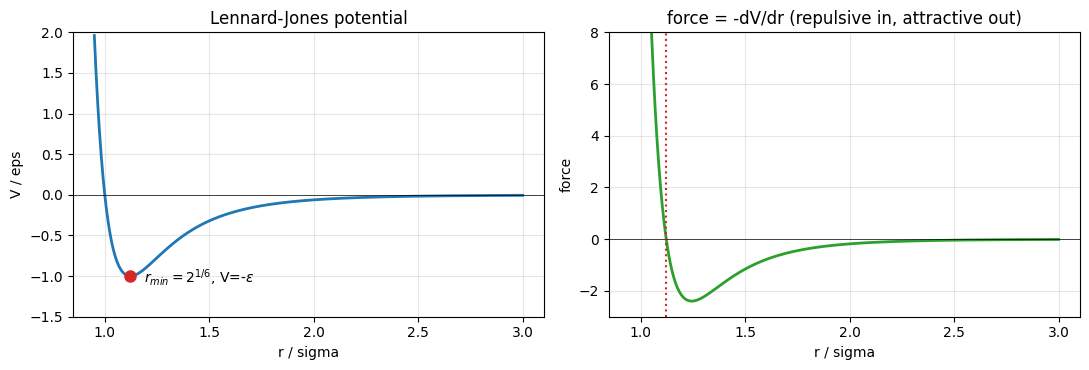

In [2]:
r = np.linspace(0.95, 3.0, 500)
V = lj.lj_potential(r); F = lj.lj_force_magnitude(r)
rmin = lj.equilibrium_distance()

fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
ax[0].plot(r, V, "C0", lw=2); ax[0].axhline(0, color="k", lw=0.5)
ax[0].plot(rmin, lj.lj_potential(rmin), "C3o", ms=8)
ax[0].annotate("$r_{min}=2^{1/6}$, V=-$\\epsilon$", (rmin, -1), textcoords="offset points",
               xytext=(10, -5)); ax[0].set_ylim(-1.5, 2)
ax[0].set_xlabel("r / sigma"); ax[0].set_ylabel("V / eps"); ax[0].set_title("Lennard-Jones potential")
ax[1].plot(r, F, "C2", lw=2); ax[1].axhline(0, color="k", lw=0.5); ax[1].axvline(rmin, color="C3", ls=":")
ax[1].set_ylim(-3, 8); ax[1].set_xlabel("r / sigma"); ax[1].set_ylabel("force")
ax[1].set_title("force = -dV/dr (repulsive in, attractive out)")
for a in ax:
    a.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## §2 A bond: two atoms oscillating

Start two atoms slightly stretched past $r_{\min}$ and release them. They oscillate about the
minimum — like a spring, but **anharmonic** (the well is steeper on the repulsive side), so the
motion isn't a clean sinusoid. Velocity-Verlet conserves the total energy to one part in $10^5$.

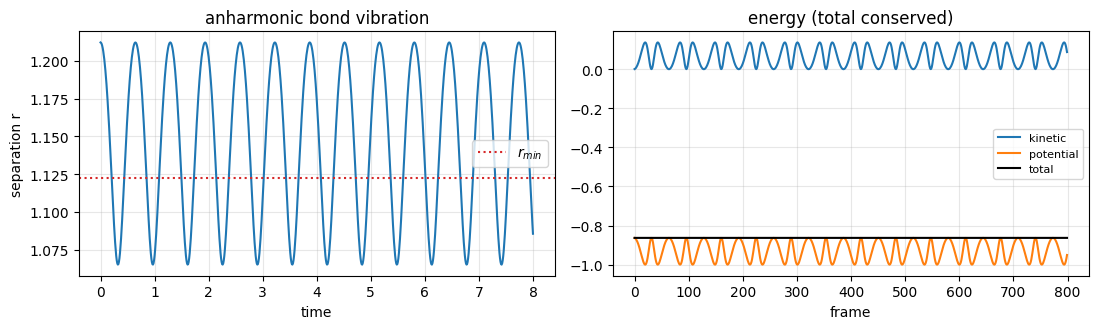

energy drift: 2.8e-05


In [3]:
pos = np.array([[0.0, 0.0], [1.08*rmin, 0.0]])
out = lj.simulate(pos, np.zeros((2, 2)), dt=0.002, steps=4000, store_every=5)
sep = np.linalg.norm(out["traj"][:, 0] - out["traj"][:, 1], axis=1)
tt = np.arange(len(sep)) * 0.002 * 5

fig, ax = plt.subplots(1, 2, figsize=(11, 3.4))
ax[0].plot(tt, sep, "C0"); ax[0].axhline(rmin, color="C3", ls=":", label="$r_{min}$")
ax[0].set_xlabel("time"); ax[0].set_ylabel("separation r"); ax[0].set_title("anharmonic bond vibration")
ax[0].legend()
ax[1].plot(out["KE"], label="kinetic"); ax[1].plot(out["PE"], label="potential")
ax[1].plot(out["E"], "k", label="total")
ax[1].set_xlabel("frame"); ax[1].set_title("energy (total conserved)"); ax[1].legend(fontsize=8)
for a in ax:
    a.grid(alpha=0.3)
plt.tight_layout(); plt.show()
print("energy drift:", f"{(out['E'].max()-out['E'].min())/abs(out['E'].mean()):.1e}")

## §3 Molecular dynamics — a little crystal

Place 19 atoms on a hexagonal lattice at the equilibrium spacing, give them a small random thermal
kick (zero net momentum), and integrate. The cluster stays **bound** (LJ cohesion holds it together)
while the atoms jiggle — a 2-D solid at finite temperature. The force loop is $O(N^2)$ over all pairs,
the literal core of every MD code.

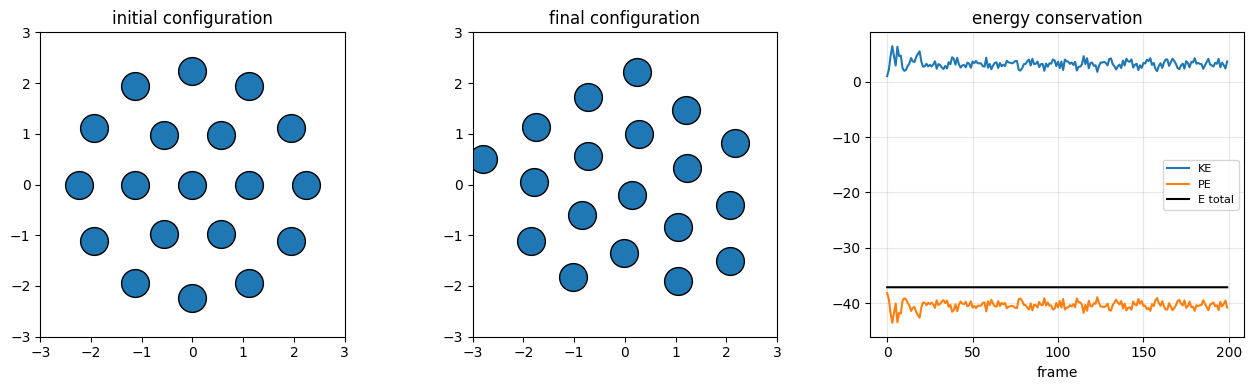

19 atoms, energy drift 4.3e-05, mean KE (temperature proxy) 3.27


In [4]:
cluster = lj.hex_cluster(n_rings=2)
rng = np.random.default_rng(1)
v0 = 0.2 * rng.standard_normal(cluster.shape); v0 -= v0.mean(0)
out = lj.simulate(cluster, v0, dt=0.003, steps=6000, store_every=30)

fig, ax = plt.subplots(1, 3, figsize=(13, 4))
for a, frame, lab in zip(ax[:2], (0, -1), ("initial", "final")):
    p = out["traj"][frame]
    a.scatter(p[:, 0], p[:, 1], s=400, c="C0", edgecolors="k")
    a.set_aspect("equal"); a.set_title(f"{lab} configuration"); a.set_xlim(-3, 3); a.set_ylim(-3, 3)
ax[2].plot(out["KE"], label="KE"); ax[2].plot(out["PE"], label="PE"); ax[2].plot(out["E"], "k", label="E total")
ax[2].set_xlabel("frame"); ax[2].set_title("energy conservation"); ax[2].legend(fontsize=8); ax[2].grid(alpha=0.3)
plt.tight_layout(); plt.show()
print(f"{len(cluster)} atoms, energy drift {(out['E'].max()-out['E'].min())/abs(out['E'].mean()):.1e}, "
      f"mean KE (temperature proxy) {out['KE'].mean():.2f}")

## §4 Connections

- **The potential IS an energy landscape, and MD is motion on it.** Force $=-\nabla V$, so molecular
  dynamics is inertial descent on the LJ surface. Strip the inertia and you get plain gradient
  descent to the nearest minimum — the same move as the gradient-descent phase retrieval in
  `dispersion_gs_gradient_descent.ipynb`. Energy minimisation, structure relaxation, and optimisation
  are one idea; the LJ well is the textbook landscape.
- **Electron clouds, made quantitative.** The $r^{-12}$ wall is Pauli exclusion (the same exclusion
  behind the periodic table and tunnelling barriers); the $r^{-6}$ tail is induced-dipole attraction
  — the static end of the polarizability $\alpha$ from the dielectrics notebook.
- **Verlet is symplectic.** Its near-perfect energy conservation (drift $\sim10^{-5}$ over thousands
  of steps) is why it, not naive Euler, runs every MD engine — it preserves phase-space volume, the
  Hamiltonian structure of the dynamics.
- **Scale-up.** The $O(N^2)$ loop here is the honest baseline; real simulations use neighbour lists
  and the FFT-based Ewald sum (yet another FFT) to reach millions of atoms.

Engine added this session: `lennard_jones.py` (potential, force, pairwise loop, velocity-Verlet MD,
hex cluster), benchmarked in `scripts/smoke_lj.py`.